# Analysis of the MLOps Pipeline in Motion – PENTION-M

In this notebook we analyze the operational performance of the MLOps pipeline in motion:

- End-to-end latency as seen by the client (`e2e_latency_ms`)
- Internal latency measured by the monitoring service (`svc_latency_ms`)
- Physical drift score based on PIML monitoring (`drift_score`)
- Model stability and version (`model_version`)
- Correlation between drift, latency, and NPS classifier confidence
- Link to monitoring logs (`/logs/monitoring_log.jsonl`)

The data comes from the script:

```text
validation/MLOps/mlops_pipeline_stress_test.py
which executed N consecutive simulations against the mlops_ingestion service.

### Import and configuration

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
RESULTS_CSV = os.path.join(ROOT_DIR, "validation", "MLOps", "mlops_stress_results.csv")
MONITORING_LOG = os.path.join(ROOT_DIR, "logs", "monitoring_log.jsonl")
RESULTS_CSV, MONITORING_LOG

('c:\\Users\\marco\\Desktop\\Marco\\Universita\\Magistrale\\Traineeship\\Progetto\\Pention-System\\validation\\MLOps\\mlops_stress_results.csv',
 'c:\\Users\\marco\\Desktop\\Marco\\Universita\\Magistrale\\Traineeship\\Progetto\\Pention-System\\logs\\monitoring_log.jsonl')

### Loading stress test results

In [ ]:
df = pd.read_csv(RESULTS_CSV)
print("Number of runs:", len(df))
df.head()

Numero di run: 20


,run_id,simulation_id,t_start_iso,e2e_latency_ms,latency_ms,drift_score,stability_index,confidence,model_version,mse_free,...,mlops_monitoring_cpu,mlops_monitoring_mem,gaussian_dispersion_model_cpu,gaussian_dispersion_model_mem,correction_dispersion_piml_cpu,correction_dispersion_piml_mem,loc_emission_source_piml_cpu,loc_emission_source_piml_mem,clas_nps_cpu,clas_nps_mem
0,1,STRESS_20251208_180157_001,2025-12-08T18:01:59.823173Z,4793.56,6799,0.0000,3.0,0.980708,PIML_v7,NaN,...,0.13,0.22,0.19,0.7,0.19,4.52,0.22,0.90,0.20,4.04
1,2,STRESS_20251208_180204_002,2025-12-08T18:02:06.687419Z,4926.01,6913,0.0000,4.0,0.971163,PIML_v7,NaN,...,0.15,0.23,0.15,0.7,0.21,5.10,0.14,0.91,0.16,4.04
2,3,STRESS_20251208_180211_003,2025-12-08T18:02:13.684260Z,5095.48,7083,0.0000,4.0,0.984074,PIML_v7,NaN,...,0.15,0.22,0.13,0.7,0.20,5.51,0.13,0.91,0.15,4.04
3,4,STRESS_20251208_180218_004,2025-12-08T18:02:20.850408Z,5016.65,7007,0.0000,4.0,0.958592,PIML_v7,NaN,...,0.12,0.23,0.15,0.7,0.21,4.55,0.15,0.91,0.15,4.04
4,5,STRESS_20251208_180225_005,2025-12-08T18:02:27.941948Z,4804.38,6796,0.9985,4.0,0.955184,PIML_v7,NaN,...,0.13,0.22,0.14,0.7,0.20,5.13,0.14,0.90,0.16,4.04


### Basic cleaning and overview

In [ ]:
for col in ["e2e_latency_ms", "latency_ms", "drift_score", "stability_index", "confidence"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df_ok = df[df["http_status"] == 200].copy()
print("Number of runs:", len(df))
print("Number of runs with http_status == 200:", len(df_ok))
df_ok.describe()[["e2e_latency_ms", "latency_ms", "drift_score", "stability_index", "confidence"]]

Run totali: 20
Run con http_status == 200: 20


,e2e_latency_ms,latency_ms,drift_score,stability_index,confidence
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,5049.628500,7045.200000,0.765195,3.600000,0.908378
std,280.487741,281.026052,0.398639,1.231174,0.101058
min,4368.950000,6358.000000,0.000000,1.000000,0.649807
25%,4889.152500,6884.500000,0.830925,3.000000,0.888021
50%,5071.870000,7073.500000,0.970850,4.000000,0.956852
75%,5269.062500,7262.750000,0.998850,4.000000,0.976366
max,5593.320000,7586.000000,1.000000,6.000000,0.985381


### Latency boxplot

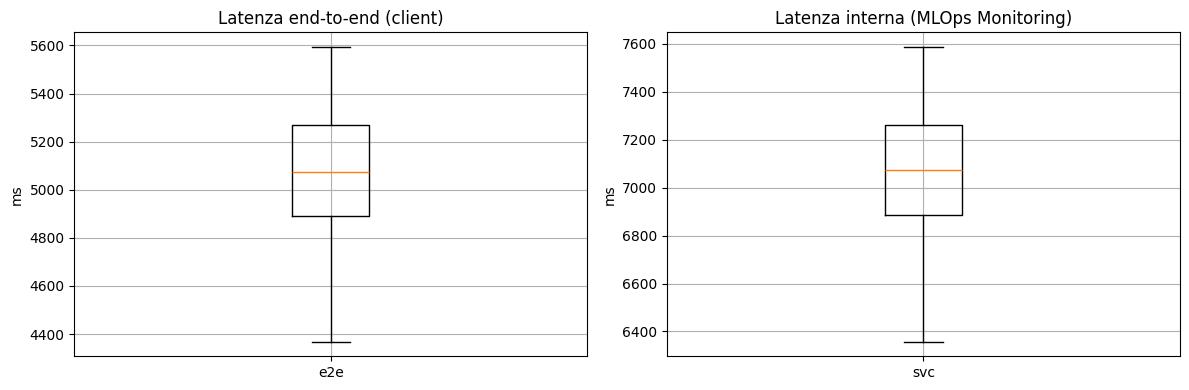

In [ ]:
data = []
labels = []

if "e2e_latency_ms" in df_ok.columns:
    data.append(df_ok["e2e_latency_ms"].dropna())
    labels.append("Client end-to-end")
if "latency_ms" in df_ok.columns:
    data.append(df_ok["latency_ms"].dropna())
    labels.append("Monitoring latency (pipeline)")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_ok["e2e_latency_ms"].dropna())
axes[0].set_title("Latenza end-to-end (client)")
axes[0].set_ylabel("ms")
axes[0].set_xticklabels(["e2e"])
axes[1].boxplot(df_ok["latency_ms"].dropna())
axes[1].set_title("Latenza interna (MLOps Monitoring)")
axes[1].set_ylabel("ms")
axes[1].set_xticklabels(["svc"])
plt.tight_layout()
plt.show()

### Drift score boxplot

C:\Users\marco\AppData\Local\Temp\ipykernel_29280\2154854674.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df_ok["drift_score"].dropna(), labels=["drift_score"])


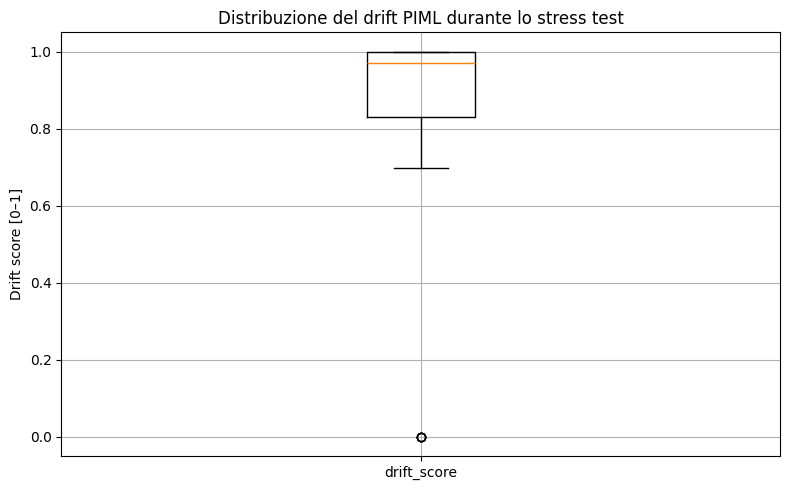

In [ ]:
if "drift_score" in df_ok.columns:
    fig, ax = plt.subplots()
    ax.boxplot(df_ok["drift_score"].dropna(), labels=["drift_score"])
    ax.set_ylabel("Drift score [0–1]")
    ax.set_title("PIML drift distribution during stress test")
    plt.tight_layout()
    plt.show()
else:
    print("The 'drift_score' column is missing from the results.")

### Latency and drift over time (per run)

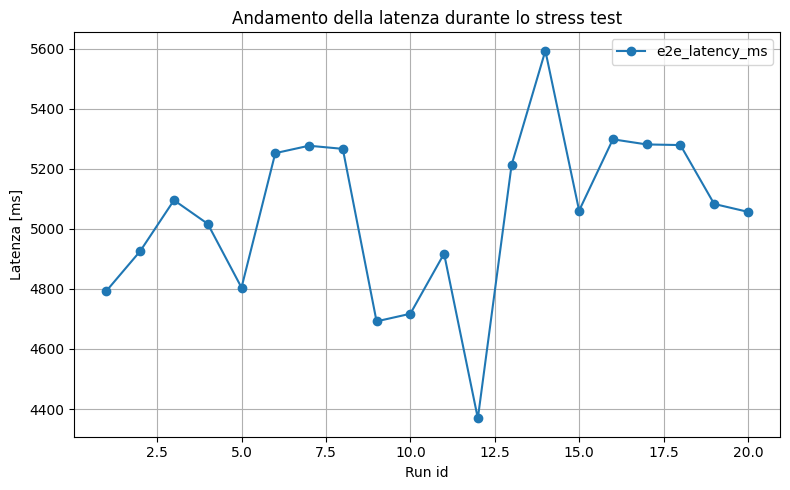

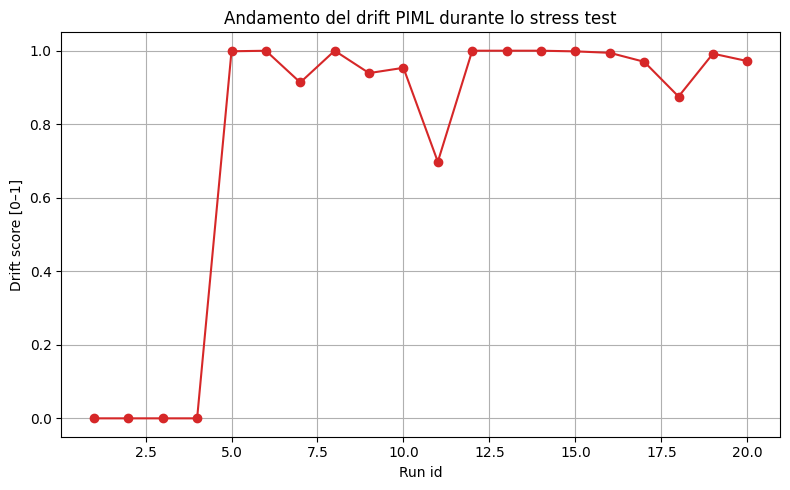

In [ ]:
if "run_id" in df_ok.columns:
    x = df_ok["run_id"]
    fig, ax1 = plt.subplots()
    ax1.plot(x, df_ok["e2e_latency_ms"], marker="o", label="e2e_latency_ms")
    ax1.set_xlabel("Run id")
    ax1.set_ylabel("Latency [ms]")
    ax1.set_title("Latency trend during the stress test")
    ax1.legend()
    plt.tight_layout()
    plt.show()

    if "drift_score" in df_ok.columns:
        fig, ax2 = plt.subplots()
        ax2.plot(x, df_ok["drift_score"], marker="o", color="tab:red")
        ax2.set_xlabel("Run id")
        ax2.set_ylabel("Drift score [0–1]")
        ax2.set_title("PIML drift trend during the stress test")
        plt.tight_layout()
        plt.show()

### Correlation between drift, latency and confidence

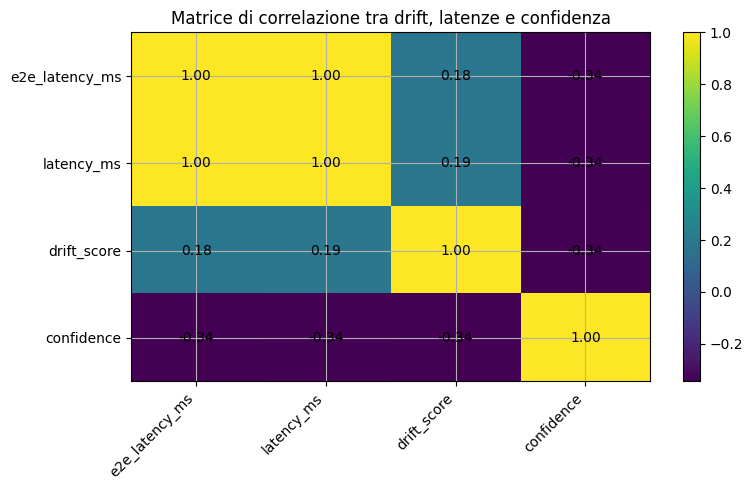

In [ ]:
cols_for_corr = []

for col in ["e2e_latency_ms", "latency_ms", "drift_score", "confidence"]:
    if col in df_ok.columns:
        cols_for_corr.append(col)

df_corr = df_ok[cols_for_corr].dropna()
if len(cols_for_corr) >= 2 and not df_corr.empty:
    corr = df_corr.corr()
    fig, ax = plt.subplots()
    im = ax.imshow(corr.values, aspect="auto")
    ax.set_xticks(range(len(cols_for_corr)))
    ax.set_yticks(range(len(cols_for_corr)))
    ax.set_xticklabels(cols_for_corr, rotation=45, ha="right")
    ax.set_yticklabels(cols_for_corr)
    for i in range(len(cols_for_corr)):
        for j in range(len(cols_for_corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")
    ax.set_title("Correlation matrix between drift, latencies and confidence")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns to calculate correlation.")

### Model Version Analysis

Distribuzione dei run per model_version:


model_version
PIML_v7    20
Name: count, dtype: int64

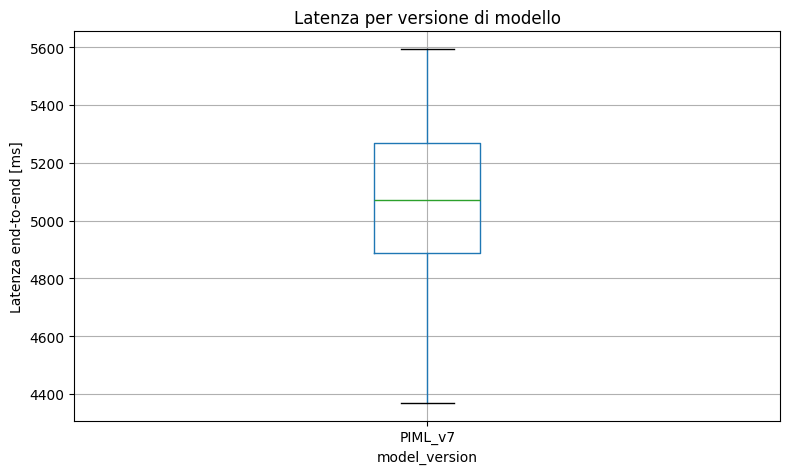

In [ ]:
if "model_version" in df_ok.columns:
    print("Distribution of runs by model_version:")
    display(df_ok["model_version"].value_counts())
    fig, ax = plt.subplots()
    df_ok.boxplot(column="e2e_latency_ms", by="model_version", ax=ax)
    ax.set_ylabel("End-to-end latency [ms]")
    ax.set_title("End-to-end latency per model version")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'model_version' not present in the results.")

### Connection with monitoring_log.jsonl (mse_free, real drift)

In [ ]:
def load_monitoring_log(path, last_n=None):
    if not os.path.exists(path):
        print(f"File non trovato: {path}")
        return pd.DataFrame()

    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    if last_n is not None and last_n > 0:
        rows = rows[-last_n:]
    return pd.DataFrame(rows)

mon_df = load_monitoring_log(MONITORING_LOG, last_n=500)
print("Rows in monitoring_log.jsonl:", len(mon_df))
mon_df.tail()

Righe nel monitoring_log.jsonl: 21


,time,simulation_id,model_version,latency_ms,drift_score,mse_free,stability_index,confidence
16,2025-12-08T18:03:51.217335,STRESS_20251208_180343_016,PIML_v7,7293,0.9943,0.114219,5.0,0.956378
17,2025-12-08T18:03:58.583613,STRESS_20251208_180351_017,PIML_v7,7281,0.9699,0.098410,4.0,0.985381
18,2025-12-08T18:04:05.931927,STRESS_20251208_180358_018,PIML_v7,7268,0.8753,0.092185,4.0,0.688325
19,2025-12-08T18:04:13.097104,STRESS_20251208_180406_019,PIML_v7,7075,0.9920,0.092098,4.0,0.922946
20,2025-12-08T18:04:20.252104,STRESS_20251208_180413_020,PIML_v7,7072,0.9718,0.107209,3.0,0.818045


### Comparison of drift and mse_free from the monitoring log

,time,simulation_id,model_version,latency_ms,drift_score,mse_free
11,2025-12-08T18:03:15.283827,STRESS_20251208_180308_011,PIML_v7,6918,0.6978,0.095344
12,2025-12-08T18:03:21.721395,STRESS_20251208_180315_012,PIML_v7,6358,1.0000,0.091632
13,2025-12-08T18:03:29.028016,STRESS_20251208_180321_013,PIML_v7,7222,1.0000,0.112950
14,2025-12-08T18:03:36.696558,STRESS_20251208_180329_014,PIML_v7,7586,1.0000,0.154324
15,2025-12-08T18:03:43.819233,STRESS_20251208_180336_015,PIML_v7,7038,0.9982,0.089443
16,2025-12-08T18:03:51.217335,STRESS_20251208_180343_016,PIML_v7,7293,0.9943,0.114219
17,2025-12-08T18:03:58.583613,STRESS_20251208_180351_017,PIML_v7,7281,0.9699,0.098410
18,2025-12-08T18:04:05.931927,STRESS_20251208_180358_018,PIML_v7,7268,0.8753,0.092185
19,2025-12-08T18:04:13.097104,STRESS_20251208_180406_019,PIML_v7,7075,0.9920,0.092098
20,2025-12-08T18:04:20.252104,STRESS_20251208_180413_020,PIML_v7,7072,0.9718,0.107209


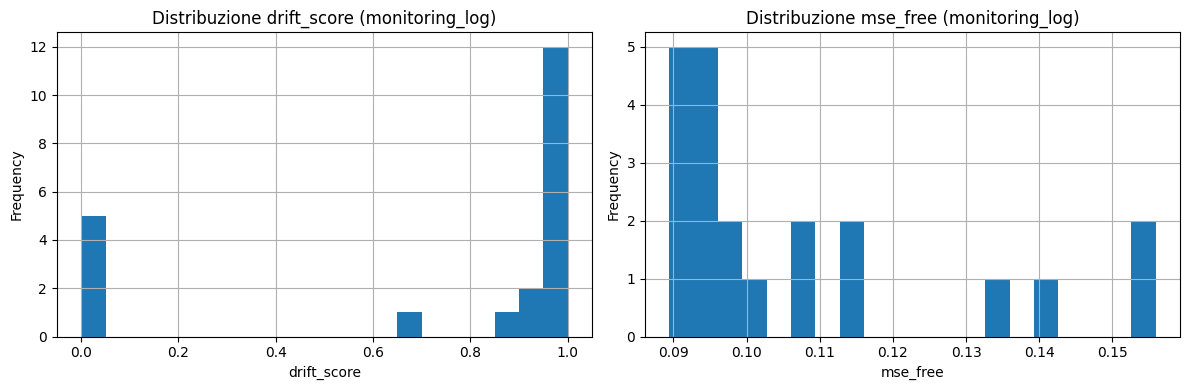

In [ ]:
if not mon_df.empty:
    for col in ["latency_ms", "drift_score", "mse_free"]:
        if col in mon_df.columns:
            mon_df[col] = pd.to_numeric(mon_df[col], errors="coerce")

    display(mon_df[["time", "simulation_id", "model_version", "latency_ms", "drift_score", "mse_free"]].tail(10))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    mon_df["drift_score"].dropna().plot(kind="hist", bins=20, ax=axes[0])
    axes[0].set_title("Distribuzione drift_score (monitoring_log)")
    axes[0].set_xlabel("drift_score")
    mon_df["mse_free"].dropna().plot(kind="hist", bins=20, ax=axes[1])
    axes[1].set_title("Distribuzione mse_free (monitoring_log)")
    axes[1].set_xlabel("mse_free")
    plt.tight_layout()
    plt.show()
else:
    print("monitoring log empty or unavailable.")

### Numerical synthesis for the thesis

In [ ]:
summary = {}
if not df_ok.empty:
    summary["n_runs_ok"] = len(df_ok)
    summary["e2e_latency_ms_mean"] = df_ok["e2e_latency_ms"].mean()
    summary["e2e_latency_ms_p95"] = df_ok["e2e_latency_ms"].quantile(0.95)
    if "latency_ms" in df_ok.columns:
        summary["latency_ms_mean"] = df_ok["latency_ms"].mean()
    if "drift_score" in df_ok.columns:
        summary["drift_score_mean"] = df_ok["drift_score"].mean()
        summary["drift_score_max"] = df_ok["drift_score"].max()
    if "confidence" in df_ok.columns:
        summary["confidence_mean"] = df_ok["confidence"].mean()
summary

{'n_runs_ok': 20,
 'e2e_latency_ms_mean': 5049.628500000001,
 'e2e_latency_ms_p95': 5313.013000000001,
 'latency_ms_mean': 7045.2,
 'drift_score_mean': 0.7651950000000001,
 'drift_score_max': 1.0,
 'confidence_mean': 0.9083781629800797}

### S-MLOps Stability Summary Figure

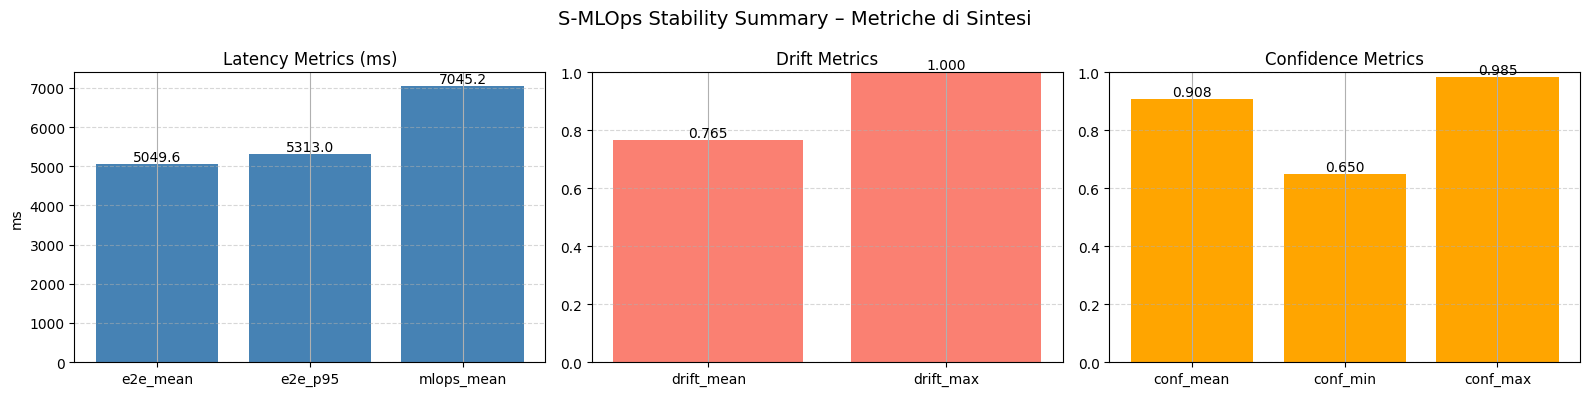

In [ ]:
import matplotlib.pyplot as plt

latency_metrics = {
    "e2e_mean": df_ok["e2e_latency_ms"].mean(),
    "e2e_p95": df_ok["e2e_latency_ms"].quantile(0.95),
    "mlops_mean": df_ok["latency_ms"].mean(),
}
drift_metrics = {
    "drift_mean": df_ok["drift_score"].mean(),
    "drift_max": df_ok["drift_score"].max(),
}
confidence_metrics = {
    "conf_mean": df_ok["confidence"].mean(),
    "conf_min": df_ok["confidence"].min(),
    "conf_max": df_ok["confidence"].max(),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(latency_metrics.keys(), latency_metrics.values(), color="steelblue")
axes[0].set_title("Latency Metrics (ms)")
axes[0].set_ylabel("ms")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
for label, value in latency_metrics.items():
    axes[0].text(label, value, f"{value:.1f}", ha="center", va="bottom")
axes[1].bar(drift_metrics.keys(), drift_metrics.values(), color="salmon")
axes[1].set_title("Drift Metrics")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
for label, value in drift_metrics.items():
    axes[1].text(label, value, f"{value:.3f}", ha="center", va="bottom")
axes[2].bar(confidence_metrics.keys(), confidence_metrics.values(), color="orange")
axes[2].set_title("Confidence Metrics")
axes[2].set_ylim(0, 1)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)
for label, value in confidence_metrics.items():
    axes[2].text(label, value, f"{value:.3f}", ha="center", va="bottom")
plt.suptitle("S-MLOps Stability Summary – Summary Metrics", fontsize=14)
plt.tight_layout()
plt.show()


### Data Flow Diagram – Stress Test Pipeline (Matplotlib)

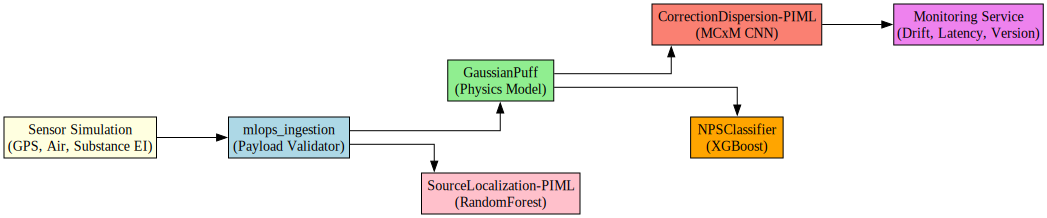

In [ ]:
import graphviz
from graphviz import Digraph

dot = Digraph("MLOps_Pipeline", format="png")
dot.attr(rankdir="LR", splines="ortho", nodesep="1", ranksep="1")
dot.node("sensor", "Sensor Simulation\n(GPS, Air, Substance EI)", shape="box", style="filled", fillcolor="lightyellow")
dot.node("ingestion", "mlops_ingestion\n(Payload Validator)", shape="box", style="filled", fillcolor="lightblue")
dot.node("gauss", "GaussianPuff\n(Physics Model)", shape="box", style="filled", fillcolor="lightgreen")
dot.node("piml", "CorrectionDispersion-PIML\n(MCxM CNN)", shape="box", style="filled", fillcolor="salmon")
dot.node("src_loc", "SourceLocalization-PIML\n(RandomForest)", shape="box", style="filled", fillcolor="pink")
dot.node("clf", "NPSClassifier\n(XGBoost)", shape="box", style="filled", fillcolor="orange")
dot.node("mon", "Monitoring Service\n(Drift, Latency, Version)", shape="box", style="filled", fillcolor="violet")
dot.edge("sensor", "ingestion")
dot.edge("ingestion", "gauss")
dot.edge("gauss", "piml")
dot.edge("ingestion", "src_loc")
dot.edge("gauss", "clf")
dot.edge("piml", "mon")
dot.render("mlops_pipeline_diagram", view=False)
dot

### Nature of the Stress Test

The executed stress test is not aimed at meeting a real-time SLA,
but at evaluating the robustness of the MLOps architecture under conditions of
variable and physically noisy inputs. In particular:

- the simulated sensors include noise, jitter, dropout, and non-linear scaling;
- the pipeline calls GaussianPuff (a computationally expensive physical model);
- the MCxM_CNN network performs urban correction on 500×500 maps;
- the XGBoost classifier operates on a randomized EI spectrum;
- the monitoring service computes PIML drift and physical metrics.

In this context, latencies between 5 and 10 seconds are fully acceptable,
as they correspond to a simulated cyber-physical system, not to a lightweight
transactional process. Outliers above 9 seconds represent compute-heavy load
situations and are appropriate in a stress-testing scenario.
